# Laboratorio 12: intervalo de confianza del 95 % con Python

**Asignatura:** Analítica de Datos  
**Docente:** Luis Miguel Gómez Meneses  
**Universidad:** Universidad Cooperativa de Colombia  
**Programa:** Ingeniería de Software

## Propósito
Utilizar una muestra aleatoria para estimar la media poblacional del peso de los productos mediante un intervalo de confianza del 95 %.

$$\text{Población} \rightarrow \text{Muestra} \rightarrow \bar{x} \rightarrow SE \rightarrow IC_{95\%}$$

## Objetivos

1. Diferenciar entre población y muestra.
2. Extraer una muestra aleatoria con Python.
3. Calcular la media, la desviación estándar y el error estándar.
4. Construir e interpretar un intervalo de confianza del 95 %.
5. Analizar el efecto del tamaño muestral sobre la precisión.

### Pregunta orientadora
> ¿Entre qué valores plausibles se encuentra la media poblacional del peso de los productos?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Carga de los datos

Cargue en el entorno el archivo `datos_distribuciones.csv`. En Google Colab puede utilizar el panel **Archivos** ubicado a la izquierda.

In [2]:
datos = pd.read_csv('/content/datos_distribuciones.csv')

print('Dimensiones:', datos.shape)
display(datos.head())
datos.info()

Dimensiones: (1000, 5)


,id,compras_exitosas,errores_hora,tiempo_respuesta,peso_producto
0,1,7,5,0.080113,546.827611
1,2,3,4,7.569356,524.451797
2,3,5,2,0.555077,500.940658
3,4,6,5,2.177190,493.162475
4,5,8,8,3.653941,504.966896


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1000 non-null   int64  
 1   compras_exitosas  1000 non-null   int64  
 2   errores_hora      1000 non-null   int64  
 3   tiempo_respuesta  1000 non-null   float64
 4   peso_producto     1000 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 39.2 KB


## 2. Exploración de `peso_producto`

Seleccionamos la variable cuantitativa y eliminamos posibles valores nulos. Para efectos del laboratorio, consideraremos los 1000 registros del dataset como una **población didáctica**. En una investigación real normalmente no conoceríamos toda la población.

In [3]:
pesos = datos['peso_producto'].dropna()
pesos.describe()

,peso_producto
count,1000.000000
mean,498.665934
std,24.989768
min,410.448435
25%,482.774230
50%,499.283067
75%,515.348200
max,575.367793


**Preguntas:**

1. ¿Cuántas observaciones válidas tiene la variable?
2. ¿Cuál es su media?
3. ¿Cuál es su desviación estándar?
4. ¿Por qué `peso_producto` es una variable cuantitativa continua?

## 3. Selección de una muestra aleatoria

Extraeremos 100 productos. `random_state=42` permite obtener la misma muestra cada vez que se ejecuta el código.

In [4]:
tamaño_muestra = 100
muestra = pesos.sample(n=tamaño_muestra, random_state=42)
print('Tamaño de la muestra:', muestra.shape[0])
display(muestra.head())

Tamaño de la muestra: 100


,peso_producto
521,504.234376
737,486.863540
740,489.620618
660,482.752101
411,526.529857


## 4. Estadísticas muestrales

Calcularemos el tamaño de la muestra $n$, la media muestral $\bar{x}$ y la desviación estándar muestral $s$. La media muestral es la estimación puntual inicial de la media poblacional $\mu$.

In [5]:
n = muestra.count()
media_muestral = muestra.mean()
desviacion_muestral = muestra.std(ddof=1)
print(f'Tamaño de la muestra: {n}')
print(f'Media muestral: {media_muestral:.2f} g')
print(f'Desviación estándar muestral: {desviacion_muestral:.2f} g')

Tamaño de la muestra: 100
Media muestral: 496.83 g
Desviación estándar muestral: 23.57 g


## 5. Error estándar

El error estándar mide cuánto tienden a variar las medias obtenidas de diferentes muestras:

$$SE=\frac{s}{\sqrt{n}}$$

No debe confundirse con la desviación estándar: la desviación estándar describe la dispersión de los valores individuales; el error estándar describe la variabilidad de las medias muestrales.

In [6]:
error_estandar = desviacion_muestral / np.sqrt(n)
print(f'Error estándar: {error_estandar:.2f} g')

Error estándar: 2.36 g


## 6. Intervalo de confianza del 95 %

Para este ejercicio introductorio, con una muestra de 100 observaciones, utilizaremos la aproximación normal con valor crítico $1.96$:

$$ME=1.96(SE)$$

$$IC_{95\%}=[\bar{x}-ME,\;\bar{x}+ME]$$

In [7]:
valor_critico = 1.96
margen_error = valor_critico * error_estandar
limite_inferior = media_muestral - margen_error
limite_superior = media_muestral + margen_error

resultados_ic = pd.DataFrame({
    'Medida': [
        'Tamaño de la muestra',
        'Media muestral (g)',
        'Desviación estándar muestral (g)',
        'Error estándar (g)',
        'Margen de error (g)',
        'Límite inferior (g)',
        'Límite superior (g)'
    ],
    'Resultado': [
        n, media_muestral, desviacion_muestral, error_estandar,
        margen_error, limite_inferior, limite_superior
    ]
})

display(resultados_ic.round(2))
print(f'IC del 95 %: [{limite_inferior:.2f}, {limite_superior:.2f}] g')

,Medida,Resultado
0,Tamaño de la muestra,100.00
1,Media muestral (g),496.83
2,Desviación estándar muestral (g),23.57
3,Error estándar (g),2.36
4,Margen de error (g),4.62
5,Límite inferior (g),492.20
6,Límite superior (g),501.45


IC del 95 %: [492.20, 501.45] g


### Preguntas de análisis y respuestas

**1. ¿Cuál fue la media obtenida en la muestra de 100 productos?**

La media muestral fue de **496,83 g**. Este valor representa el peso promedio de los 100 productos seleccionados.



**2. ¿Qué representa el error estándar de 2,36 g?**

El error estándar representa la variabilidad esperada de las medias obtenidas al seleccionar diferentes muestras de 100 productos de la misma población. Un error estándar menor indica una estimación más precisa de la media poblacional.


**3. ¿Cuáles son los límites inferior y superior del intervalo de confianza del 95 %?**

El límite inferior es **492,20 g** y el límite superior es **501,45 g**. Por tanto:

$
IC_{95\%}=[492,20,\ 501,45]\text{ g}
$

**4. ¿Qué parámetro de la población estamos estimando mediante este intervalo?**

Estamos estimando la **media poblacional del peso de los productos**, representada mediante \(\mu\).

**5. ¿Sería correcto afirmar que el 95 % de los productos pesa entre 492,20 g y 501,45 g? Justifique su respuesta.**

No es correcto. El intervalo de confianza no describe el peso del 95 % de los productos individuales. Este intervalo se utiliza para estimar el valor de la **media poblacional** del peso de los productos..

## 7. Representación gráfica del intervalo

El punto representa la media muestral y la línea horizontal representa el intervalo de confianza.

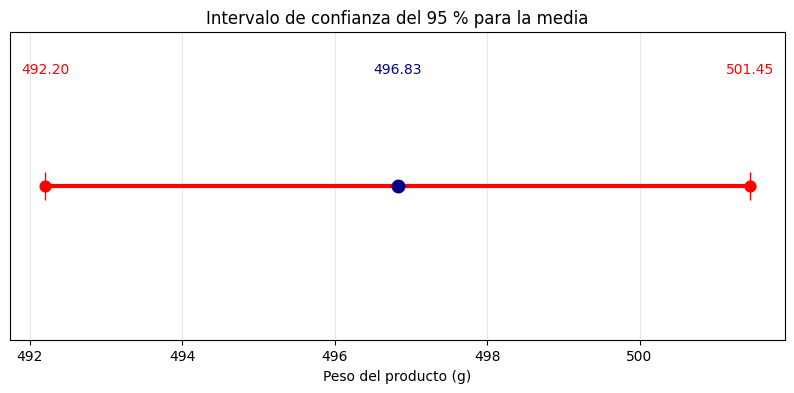

In [8]:
plt.figure(figsize=(10, 4))
plt.errorbar(
    x=media_muestral, y=0, xerr=margen_error,
    fmt='o', color='darkblue', ecolor='red',
    elinewidth=3, capsize=10, markersize=9
)
plt.scatter([limite_inferior, limite_superior], [0, 0], color='red', s=60)
plt.text(limite_inferior, 0.04, f'{limite_inferior:.2f}', ha='center', color='red')
plt.text(media_muestral, 0.04, f'{media_muestral:.2f}', ha='center', color='darkblue')
plt.text(limite_superior, 0.04, f'{limite_superior:.2f}', ha='center', color='red')
plt.yticks([])
plt.xlabel('Peso del producto (g)')
plt.title('Intervalo de confianza del 95 % para la media')
plt.grid(axis='x', alpha=0.3)
plt.show()

### Preguntas de análisis de la gráfica

**1. ¿Qué representa el punto azul ubicado en 496,83 g?**

El punto azul representa la **media de la muestra de 100 productos**. Esta media muestral se utiliza como estimación puntual de la media poblacional.

**2. ¿Qué representan los valores 492,20 g y 501,45 g?**

Representan los límites del intervalo de confianza del 95 %:

- **492,20 g:** límite inferior.
- **501,45 g:** límite superior.

Este intervalo se utiliza para estimar dónde podría encontrarse la media poblacional del peso.

**3. ¿Qué representa la línea roja de la gráfica?**

La línea roja representa el intervalo de confianza del 95 %. Muestra el rango de valores plausibles para la media poblacional a partir de la muestra analizada.

**4. ¿Cuál es el margen de error del intervalo?**

El margen de error es aproximadamente **4,62 g**. Corresponde a la distancia entre la media muestral y cada uno de los límites del intervalo:

$$
ME \approx 501,45-496,83=4,62\text{ g}
$$

Por diferencias ocasionadas por el redondeo, la distancia con respecto al límite inferior puede variar ligeramente.

**5. Si un producto individual pesa 510 g, ¿podemos afirmar que su peso es incorrecto porque está fuera de la línea roja?**

No. La línea roja no representa el rango esperado para los pesos individuales. Representa un intervalo utilizado para estimar la **media poblacional**.

Por tanto, un producto puede pesar 510 g, 520 g o presentar otro valor fuera del intervalo sin que necesariamente sea incorrecto o atípico.

## 8. Verificación didáctica

Como en este ejercicio conocemos la población didáctica completa, podemos verificar si su media está contenida en el intervalo. En una investigación real la media poblacional normalmente sería desconocida.

In [9]:
media_poblacional_didactica = pesos.mean()
esta_contenida = limite_inferior <= media_poblacional_didactica <= limite_superior

print(f'Media de la población didáctica: {media_poblacional_didactica:.2f} g')
print(f'IC del 95 %: [{limite_inferior:.2f}, {limite_superior:.2f}] g')
print('¿La media poblacional está contenida?', esta_contenida)

Media de la población didáctica: 498.67 g
IC del 95 %: [492.20, 501.45] g
¿La media poblacional está contenida? True


## 9. Efecto del tamaño de la muestra

Construiremos intervalos con muestras de 25, 50, 100 y 200 productos para analizar el error estándar y la amplitud del intervalo.

In [10]:
tamaños = [25, 50, 100, 200]
resultados = []

for tamaño in tamaños:
    muestra_n = pesos.sample(n=tamaño, random_state=42)
    media_n = muestra_n.mean()
    desviacion_n = muestra_n.std(ddof=1)
    error_n = desviacion_n / np.sqrt(tamaño)
    margen_n = 1.96 * error_n
    inferior_n = media_n - margen_n
    superior_n = media_n + margen_n

    resultados.append({
        'Tamaño de muestra': tamaño,
        'Media muestral': media_n,
        'Error estándar': error_n,
        'Margen de error': margen_n,
        'Límite inferior': inferior_n,
        'Límite superior': superior_n,
        'Amplitud del IC': superior_n - inferior_n
    })

comparacion = pd.DataFrame(resultados)
comparacion.round(2)

,Tamaño de muestra,Media muestral,Error estándar,Margen de error,Límite inferior,Límite superior,Amplitud del IC
0,25,501.85,4.91,9.62,492.22,511.47,19.25
1,50,496.29,3.28,6.42,489.87,502.71,12.84
2,100,496.83,2.36,4.62,492.20,501.45,9.24
3,200,496.84,1.60,3.14,493.70,499.98,6.28


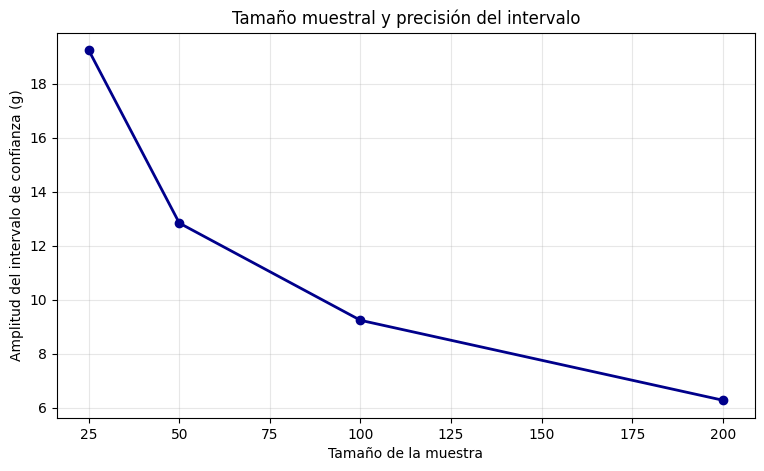

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(
    comparacion['Tamaño de muestra'],
    comparacion['Amplitud del IC'],
    marker='o', color='darkblue', linewidth=2
)
plt.xlabel('Tamaño de la muestra')
plt.ylabel('Amplitud del intervalo de confianza (g)')
plt.title('Tamaño muestral y precisión del intervalo')
plt.grid(alpha=0.3)
plt.show()

### Interpretación de la gráfica

La gráfica relaciona el **tamaño de la muestra** con la **amplitud total del intervalo de confianza**.

Los resultados muestran que:

- con 25 productos, la amplitud es de 19,25 g;
- con 50 productos, la amplitud es de 12,84 g;
- con 100 productos, la amplitud es de 9,24 g;
- con 200 productos, la amplitud es de 6,28 g.

Por tanto, a medida que aumenta el tamaño de la muestra, disminuye la amplitud del intervalo de confianza.

\[
n\uparrow \quad\Longrightarrow\quad \text{amplitud del intervalo}\downarrow
\]

Un intervalo más estrecho indica una estimación más precisa de la media poblacional.

La gráfica no representa directamente el error estándar. Sin embargo, la amplitud disminuye porque el error estándar y el margen de error también disminuyen al aumentar el tamaño de la muestra.

### Preguntas de análisis

**1. ¿Qué ocurre con la amplitud del intervalo de confianza cuando aumenta el tamaño de la muestra?**

La amplitud disminuye. El intervalo se vuelve más estrecho a medida que aumenta el tamaño de la muestra.

**2. ¿Cuál tamaño de muestra produjo el intervalo de confianza más amplio?**

La muestra de **25 productos**, con una amplitud de **19,25 g**.


**3. ¿Cuál tamaño de muestra produjo el intervalo de confianza más estrecho?**

La muestra de **200 productos**, con una amplitud de **6,28 g**.


**4. ¿Qué significa que un intervalo de confianza sea más estrecho?**

Significa que la estimación de la media poblacional es más precisa, porque el rango de valores plausibles para la media es menor.


**5. ¿Por qué disminuye la amplitud del intervalo cuando aumenta el tamaño de la muestra?**

Porque al aumentar el tamaño de la muestra disminuye el error estándar. Como consecuencia, también disminuyen el margen de error y la amplitud total del intervalo:

$$
n\uparrow
\Longrightarrow
SE\downarrow
\Longrightarrow
ME\downarrow
\Longrightarrow
\text{amplitud}\downarrow
$$